In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
import pyFAI
from pyFAI.azimuthalIntegrator import AzimuthalIntegrator;
import h5py
from scipy.ndimage import gaussian_filter

  File "/software/mamba/2024.01/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/software/mamba/2024.01/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/fperakis/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/fperakis/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/home/fperakis/.venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/fperakis/.venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/software/mamba/2024.01/lib/python3.11/asyncio/base_events.py", line 607, in run_forever
    self._run_once()
  File "/software/mamba/2024.01/lib/python3.11/asyncio/base_events.py", line 1922, in _run_once

In [2]:
import scipy.io as spio

def loadmat(filename):
    '''
    this function should be called instead of direct spio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    '''
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

def _check_keys(dict):
    '''
    checks if entries in dictionary are mat-objects. If yes
    todict is called to change them to nested dictionaries
    '''
    for key in dict:
        if isinstance(dict[key], spio.matlab.mio5_params.mat_struct):
            dict[key] = _todict(dict[key])
    return dict        

def _todict(matobj):
    '''
    A recursive function which constructs from matobjects nested dictionaries
    '''
    dict = {}
    for strg in matobj._fieldnames:
        elem = matobj.__dict__[strg]
        if isinstance(elem, spio.matlab.mio5_params.mat_struct):
            dict[strg] = _todict(elem)
        else:
            dict[strg] = elem
    return dict


In [12]:
def stretched_exponential(x,a,b,c,d):
    return np.abs(a)*np.exp(-(x/np.abs(b))**c)+d

def double_exponential(x,a,b,c,d,e):
    return np.abs(a)*np.exp(-(x/(np.abs(b)))**c)+np.abs(c)*np.exp(-(x/(np.abs(d))))+e 

def fit(function,x,y,p0=None,sigma=None, bounds=None,method={'trf'}):#bounds=((0.,0.,0.),(10., 10000.,5)),method={'trf'}):
    '''
    fits a function and return the fit resulting parameters and curve
    '''
    popt,pcov = curve_fit(function,x,y,p0=p0,sigma=sigma,bounds=bounds)
    curve = function(x,*popt)
    perr = np.sqrt(np.diag(pcov))
    return popt,x,curve,perr

### Sample name and paths

In [14]:
sample = 'NPL14B'
qBlock = 13
Temps=np.array([90,100,110,115])# '115')#'115','120','125','130','135', '140')
runs = np.array([#[129,136,145,155], #spot 0
                  [129,138,146, 160], #spot 1
                  [131,140,148,167], #spot 2
                  [134,142,150,169]]) #spot 3
path_to_data = '/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/'

### Load data

In [15]:
# load SAXS
n_spots = len(runs[:,0])
n=len(Temps)
g2=np.zeros((n_spots,n,34))#[]
Iq=np.zeros((n_spots,n,90))#[]

for i_spot in range(n_spots):
    for i in range(n): 
        file_name = path_to_data + f"%s_%05d_result.mat"%(sample,runs[i_spot,i])
        print(file_name)
        results_file = loadmat(file_name)
        Data = results_file['ccdimginfo']
        dat = Data['result']
        g = np.array(dat['g2avg'])
        g2[i_spot,i] = g[qBlock] #.append(g2[qBlock]) 
        Iqt = Data['result']['Iqphit' ]
        Iq[i_spot,i] = np.average(Iqt, axis=1) 
        if i == 0 and i_spot==0:
            q = Data['sqspan'][1:]
            x=Data['result']['delay']

/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00129_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00138_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00146_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00160_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00131_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00140_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00148_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00167_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00134_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00142_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00150_result.mat
/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00169_res

In [16]:
# load WAXS data
ai = pyFAI.load("/asap3/petra3/gpfs/p10/2026/data/11023455/shared/online_analysis/LaB6_2026-05-14.poni");
det = 'e500'

q_bins=1000
Iq_waxs=np.zeros((n_spots,n,q_bins))
for i_spot in range(n_spots):
    for i in range(n):
        samplerun = f'{sample}_{"%05d" % runs[i_spot,i]}'
        path = f'/asap3/petra3/gpfs/p10/2026/data/11023455/raw/{samplerun}/{det}/{samplerun}_master.h5'
        f = h5py.File(path)
        print(path)
        data=np.array(f['entry']['data']['data_000001']) 
        mean_ = np.mean(data, axis = 0)
        q_waxs,y = ai.integrate1d(mean_, q_bins, mask = None, unit = 'q_A^-1') # This line does the integration.
        Iq_waxs[i_spot,i] = y #np.average(y, axis=1)

/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00129/e500/NPL14B_00129_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00138/e500/NPL14B_00138_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00146/e500/NPL14B_00146_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00160/e500/NPL14B_00160_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00131/e500/NPL14B_00131_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00140/e500/NPL14B_00140_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00148/e500/NPL14B_00148_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00167/e500/NPL14B_00167_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00134/e500/NPL14B_00134_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00142/e500/NPL14B_00142_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/raw/NPL14B_00150/e500/NPL14B_00150_master.h5
/asap3/petra3/gpfs/p10/2026/data/11023455/r

## Fit and plot data

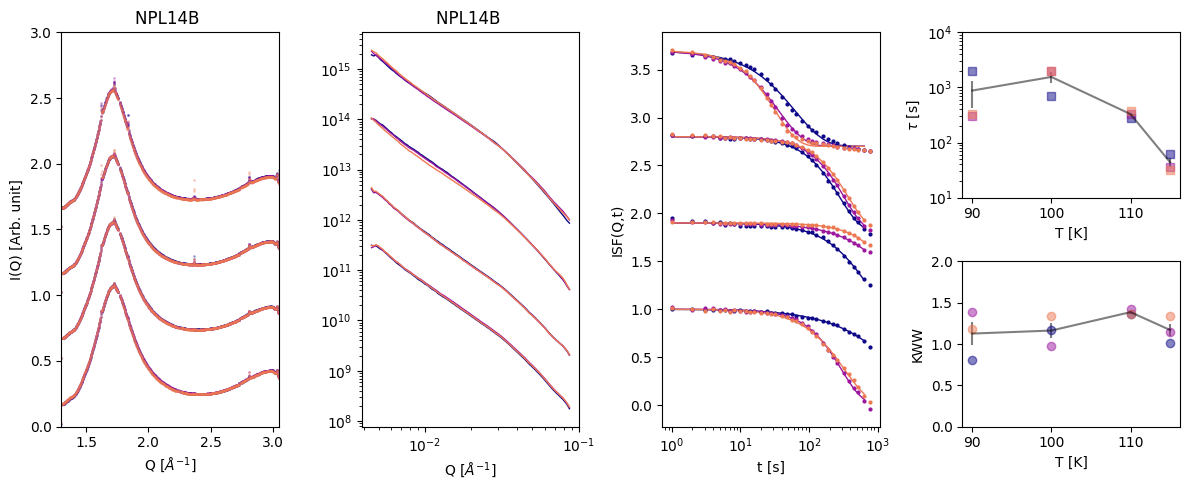

In [17]:
colors=[plt.cm.plasma(float(i)/(n_spots)) for i in range(n_spots)]
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(2, 4)

# WAXS
ax0 = fig.add_subplot(gs[:, 0])
for i_spot in range(n_spots):
    for i in range(n):
        y = Iq_waxs[i_spot,i]
        norm=y[190]
        offset = i*.5
        ax0.plot(q_waxs,y/norm+offset,ls='',marker='o',ms=1,color=colors[i_spot], alpha=0.3)
ax0.set(xlabel='Q [${Å}^{-1}$]')
ax0.set(ylabel='I(Q) [Arb. unit]')
ax0.set(title=f"%s "%(sample))#'eHDA_B, q=' + str(results_file['ccdimginfo']['dqspan'][qBlock]) + ' $\mathrm{Å^{-1}}$')
plt.ylim(0,3)
plt.xlim(1.3, 3.05)

# SAXS
ax0 = fig.add_subplot(gs[:, 1])
for i_spot in range(n_spots):
    for i in range(n):
        y = Iq[i_spot,i]    
        ax0.errorbar(q,y*(20**i+1),ls='-', alpha=1, lw=1,label=f'spot=%i'%(i_spot),color=colors[i_spot])#, s=5) #,marker=next(marker), 
        #if i==0: ax0.legend( loc='lower left', prop={'size': 8})
ax0.set(title=f"%s "%(sample))#'eHDA_B, q=' + str(results_file['ccdimginfo']['dqspan'][qBlock]) + ' $\mathrm{Å^{-1}}$')
ax0.set(xlabel='Q [${Å}^{-1}$]')
#ax0.set(ylabel='I(Q) [Arb. unit]')
ax0.set_yscale('log')
ax0.set_xscale('log')

# XPCS
tau, kww = np.zeros((n_spots, n)), np.zeros((n_spots, n))
#dtau, dkww = np.zeros((n_spots, n)), np.zeros((n_spots, n))

it = -1
scale = 0.9
ax1 = fig.add_subplot(gs[:, 2])
for i_spot in range(n_spots):
    for i in range(n):
        y = g2[i_spot,i]
        popt,x_c,curve,perr = fit(stretched_exponential,x[:it],y[:it], p0= [0.1,300,1.,1.],bounds=([0,10,0,0.9],[1,2000,2,1.1]))
        contrast, offset = abs(popt[0]), abs(popt[3])
        tau[i_spot,i],kww[i_spot,i] = abs(popt[1]), popt[2]
        ax1.errorbar(x,(y-offset)/contrast+i*scale,color=colors[i_spot],ms=2,marker='o',ls='')#, s=5) #,marker=next(marker), 
        ax1.plot(x_c,(curve-offset)/contrast+i*scale,color=colors[i_spot],lw=1) #,marker=next(marker),         
    
ax1.set(xlabel='t [s]', ylabel=r'ISF(Q,t)', xscale='log')

# tau plot
ax1 = fig.add_subplot(gs[0, 3])
for i_spot in range(n_spots):
    ax1.errorbar(Temps,tau[i_spot],marker='s',c=colors[i_spot], ls='',alpha=0.5)
ax1.errorbar(Temps,np.average(tau,axis=0),yerr=np.std(tau,axis=0)/np.sqrt(n_spots),c='black', ls='-', alpha=0.5)
ax1.set_xlabel(r"T [K]", fontsize=10)
ax1.set_ylabel(r"$\tau$ [s]", fontsize=10)
ax1.set_ylim(10,10000)
ax1.set_yscale('log')

# kww plot
ax2 = fig.add_subplot(gs[1, 3])
for i_spot in range(n_spots):
    ax2.errorbar(Temps,kww[i_spot],marker='o',c=colors[i_spot], ls='',alpha=0.5)
ax2.errorbar(Temps,np.average(kww, axis=0),yerr=np.std(kww,axis=0)/np.sqrt(n_spots),marker=' ',c='black', ls='-', alpha=0.5)    
ax2.set_ylabel(r"KWW", fontsize=10)
ax2.set_xlabel(r"T [K]", fontsize=10)
ax2.set_ylim(0,2)

plt.tight_layout()
#plt.savefig(f"%s_Ts.png"%(sample), dpi=600)
plt.show()